In [1]:
import pandas as pd
df = pd.read_csv('/content/creditcard.csv')
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
df['hour_of_day'] = (df['Time'] / 3600) % 24
df.head(20)

#Features AS X and Target as Y
X = df[[
    'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
    'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
    'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28',
    'Amount', 'hour_of_day'
]]
Y = df['Class']


In [3]:
# Splitting and scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# smote ( since our fraud is only 0.178%, creating cases to train the model like fictional balancing)

somte = SMOTE(random_state=42)
X_train_resampled, Y_train_resampled = somte.fit_resample(X_train, Y_train)

print(Y_train.value_counts())
print(Y_train_resampled.value_counts())





Class
0    167786
1       315
Name: count, dtype: int64
Class
0    167786
1    167786
Name: count, dtype: int64


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb

#training
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs = -1)
rf.fit(X_train_resampled, Y_train_resampled)

xgb_model = xgb.XGBClassifier(eval_metric = 'aucpr', n_estimators=100, random_state=42)
xgb_model.fit(X_train_resampled, Y_train_resampled)





XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [5]:
# getting classification report
import pandas as pd
from sklearn.metrics import classification_report
#testing
rf_preds = rf.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

# print("Random Forest:")
report = classification_report(Y_test, xgb_preds, output_dict = True)
report_df = pd.DataFrame(report).T

report_df

,precision,recall,f1-score,support
0,0.999785,0.999571,0.999678,41947.000000
1,0.795455,0.886076,0.838323,79.000000
accuracy,0.999358,0.999358,0.999358,0.999358
macro avg,0.897620,0.942823,0.919001,42026.000000
weighted avg,0.999401,0.999358,0.999375,42026.000000


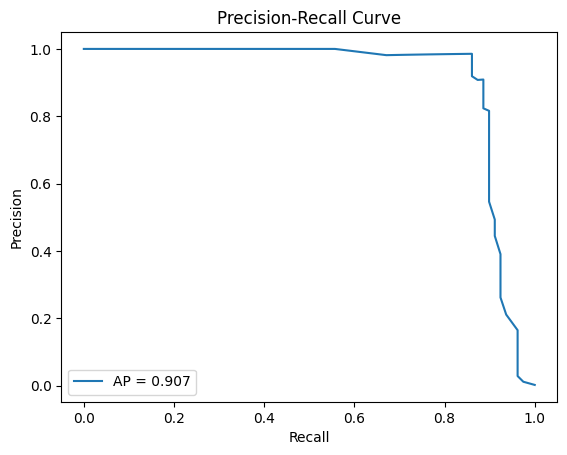

In [6]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import seaborn as sns
import matplotlib.pyplot as plt

probs = rf.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(Y_test, probs)
ap_score = average_precision_score(Y_test, probs)

plt.plot(recall, precision, label=f'AP = {ap_score:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# Creating data frame for

pr_df = pd.DataFrame({
    'precision': precision[:-1],
    'recall': recall[:-1],
    'threshold': thresholds
})
pr_df.to_csv('pr_curve.csv', index = False)

In [7]:
import pandas as pd

features = [
    'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
    'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
    'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28',
    'Amount', 'hour_of_day'
]

importance = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)


top_10 = importance.head(10)
top_10.to_csv('feature_importance', index = False)


The `df` variable appears to have been overwritten. Re-loading the original dataset to restore it as a DataFrame for the following analysis cells.

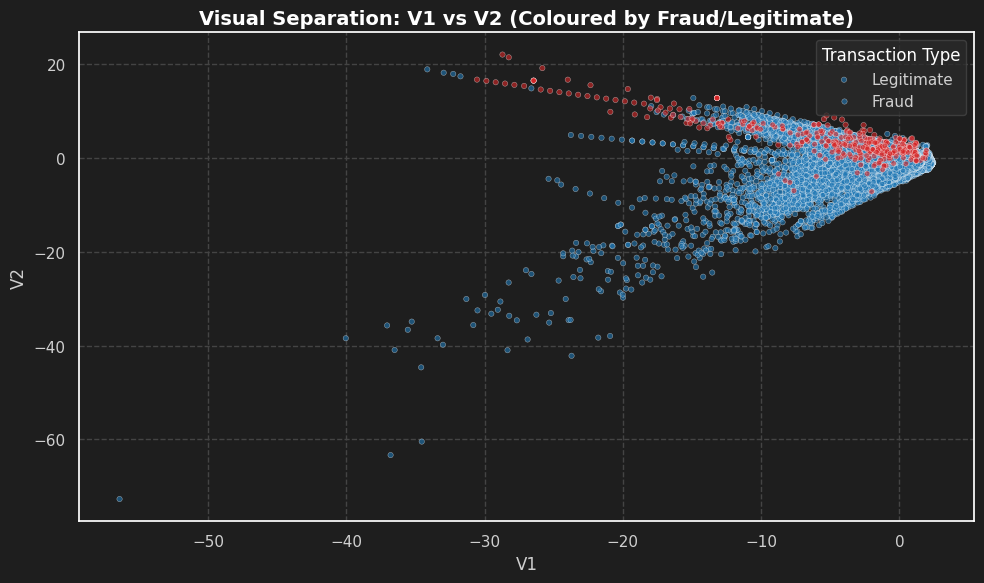

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6), facecolor='#1e1e1e')
sns.set_theme(style="darkgrid")


df_sorted = df.sort_values(by='Class')
ax = sns.scatterplot(
    x='V1',
    y='V2',
    hue='Class',
    data=df_sorted,
    palette={0: '#1f77b4', 1: '#d62728'},
    alpha=0.6,
    s=15
)

ax.set_facecolor('#1e1e1e')
ax.tick_params(colors='#cfcfcf', which='both')  # Axis numbers
ax.xaxis.label.set_color('#cfcfcf')            # V1 Label
ax.yaxis.label.set_color('#cfcfcf')            # V2 Label
ax.grid(color='#444444', linestyle='--')

plt.title('Visual Separation: V1 vs V2 (Coloured by Fraud/Legitimate)', fontsize=14, fontweight='bold', color='#ffffff')
plt.xlabel('V1', fontsize=12)
plt.ylabel('V2', fontsize=12)

legend = plt.legend(title='Transaction Type', labels=['Legitimate', 'Fraud'], facecolor='#2a2a2a', edgecolor='#444444')
plt.setp(legend.get_texts(), color='#cfcfcf')         # Legend text
plt.setp(legend.get_title(), color='#ffffff')         # Legend title

plt.tight_layout()
plt.show()

In [9]:
# Developing corealtion with fraud
import pandas as pd

correlation_with_fraud = df.corr()['Class'].sort_values(ascending=False)


correlation_with_fraud.to_csv('correlation_tab.csv',index = True)

In [10]:
# GETTING CONFUSION MATRIX

import pandas as pd
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, rf.predict(X_test))

cm_df = pd.DataFrame(cm,
      index=['Actual Legit', 'Actual Fraud'],
      columns = ['Predicted Legit', 'Predicted Fraud'])

# cm_df

cm_df.to_csv('confusion_matrix.csv', index = True)



In [16]:
#categorising on the bsais of prediction

fraud_prob = rf.predict_proba(X_test)[:, 1]
fraud_pred = rf.predict(X_test)

#test_case for dataframe

X_test_df = pd.DataFrame(X_test,columns = features)

#adding predictions
X_test_df['predicted_class'] = fraud_pred
X_test_df['fraud_probability'] = fraud_prob.round(4)
X_test_df['actual_class'] = Y_test.values
X_test_df['Amount'] = X_test_df['Amount']
X_test_df['hour_of_day'] = X_test_df['hour_of_day']

#Categorising on the basis of score.

X_test_df['risk_level'] = pd.cut(
    fraud_prob,
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High'],
    include_lowest = True
)

X_test_df.to_csv('fraud_pro.csv', index = False)







In [12]:
# XGBoost Model
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# scale_pos_weight handles imbalance
# ratio of legit to fraud in original training set
scale = Y_train.value_counts()[0] / Y_train.value_counts()[1]

xgb_model = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_resampled, Y_train_resampled)

# Evaluate
Y_pred_xgb = xgb_model.predict(X_test)

xg_report = classification_report(Y_test, Y_pred_xgb, output_dict=True)
xg_classification = pd.DataFrame(xg_report).T
xg_classification.to_csv('xg_classification', index = True)